## Reusable Code from Day 1 and Day 2 Tasks

In [32]:
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, average_precision_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

adult = fetch_openml('adult', version=2, as_frame=True)
df = adult.frame
# Convert target labels to 0 and 1
df['class'] = df['class'].str.strip().map({'<=50K': 0, '>50K': 1})
# Replace string '?' placeholders with NaN if present
df.replace('?', np.nan, inplace=True)

num_cols = df.select_dtypes(include=[np.number]).columns
cat_cols = df.select_dtypes(include=['object', 'category']).columns

X = df.drop(columns=['class'])
y = df['class']

# Stratified Hold-out Test Set (20%)
X_train_dev, X_test, y_train_dev, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# Dev set (10% of total data = 12.5% of train_dev)
X_train, X_dev, y_train, y_dev = train_test_split(
    X_train_dev, y_train_dev, test_size=0.125, random_state=42, stratify=y_train_dev
)

MajorityModel = DummyClassifier(strategy='most_frequent')
MajorityModel.fit(X_train, y_train)

MajorityPred = MajorityModel.predict(X_test)
MajorityProb = MajorityModel.predict_proba(X_test)[:, 1]

# Single-Feature Rule Baseline: education-num >= 13
# Rationale: Higher education levels are generally associated with higher income,
# making education-num a reasonable simple feature for predicting income >50K.
# This rule is intentionally simple and provides a baseline for comparison with
# more advanced machine learning models.

RulePred = (X_test['education-num'] >= 13).astype(int)
RuleScore = X_test['education-num']

def EvaluateModel(YTrue, YPred, YScore):
    return {
        'Accuracy': accuracy_score(YTrue, YPred),
        'Precision': precision_score(YTrue, YPred, zero_division=0),
        'Recall': recall_score(YTrue, YPred, zero_division=0),
        'F1': f1_score(YTrue, YPred, zero_division=0),
        'ROC AUC': roc_auc_score(YTrue, YScore),
        'PR AUC': average_precision_score(YTrue, YScore)
    }

MajorityResults = EvaluateModel(
    y_test,
    MajorityPred,
    MajorityProb
)

RuleResults = EvaluateModel(
    y_test,
    RulePred,
    RuleScore
)

MetricsTable = pd.DataFrame(
    [MajorityResults, RuleResults],
    index=['Majority Class', 'Education Rule']
)

ErrorAnalysis = X_test.copy()
ErrorAnalysis['Actual'] = y_test
ErrorAnalysis['Predicted'] = RulePred

FalsePositives = ErrorAnalysis[
    (ErrorAnalysis['Actual'] == 0) &
    (ErrorAnalysis['Predicted'] == 1)
]

FalseNegatives = ErrorAnalysis[
    (ErrorAnalysis['Actual'] == 1) &
    (ErrorAnalysis['Predicted'] == 0)
]
num_cols = df.select_dtypes(include=[np.number]).columns
num_cols = num_cols.drop('class')  # Exclude target variable from features
cat_cols = df.select_dtypes(include=['object', 'category']).columns
NumericPipeline = Pipeline([
    ('Imputer', SimpleImputer(strategy='median')),
    ('Scaler', StandardScaler())
])
CategoricalPipeline = Pipeline([
    ('Imputer', SimpleImputer(strategy='most_frequent')),
    ('Encoder', OneHotEncoder(handle_unknown='ignore'))
])

Preprocessor = ColumnTransformer([
    ('Numeric', NumericPipeline, num_cols),
    ('Categorical', CategoricalPipeline, cat_cols)
])
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

# Logistic Regression pipeline
logreg_pipeline = Pipeline([
    ("preprocessor", Preprocessor),
    ("model", LogisticRegression(
        random_state=42,
        solver="liblinear",
        max_iter=1000
    ))
])

# Decision Tree pipeline
dt_pipeline = Pipeline([
    ("preprocessor", Preprocessor),
    ("model", DecisionTreeClassifier(
        random_state=42
    ))
])

# Fit both models on the training set only
logreg_pipeline.fit(X_train, y_train)
dt_pipeline.fit(X_train, y_train)

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, confusion_matrix,
    roc_curve, precision_recall_curve, auc
)

# Predictions and probabilities for both trained pipelines
logreg_pred = logreg_pipeline.predict(X_test)
logreg_prob = logreg_pipeline.predict_proba(X_test)[:, 1]

dt_pred = dt_pipeline.predict(X_test)
dt_prob = dt_pipeline.predict_proba(X_test)[:, 1]





# Task 1
Using domain knowledge
Useful Features would include:

- Age_Buckets: Older workers may earn more than younger workers.
- Is_PartTime: Full-time workers may have higher income than part-time workers.
- Has_CapitalGain: capital_gain contains many zeros, so create a presence flag 
- Log_CapitalGain: a log-transformed version.
- Higher_Education: Education may matter more when combined with work experience or working hours.
- Is_Overtime: Overtime work may be associated with higher earnings.
- Is_Married: Marital status can act as a proxy for household and life-stage differences.


In [33]:
# Create engineered features from the original Adult dataset columns
# Age groups capture a potentially non-linear relationship between age and income.
df['Age_Buckets'] = pd.cut(
    df['age'],
    bins=[0, 25, 35, 45, 55, 65, np.inf],
    labels=['18-25', '26-35', '36-45', '46-55', '56-65', '66+'],
    include_lowest=True
)

# Part-time work is defined as fewer than 35 hours per week.
df['Is_PartTime'] = (df['hours-per-week'] < 35).astype('Int64')

# A flag distinguishes no capital gain from any capital gain.
df['Has_CapitalGain'] = (df['capital-gain'] > 0).astype('Int64')

# The log transformation reduces the influence of extremely large capital gains.
df['Log_CapitalGain'] = np.log1p(df['capital-gain'])

# This threshold identifies people with at least a bachelor's-level education.
df['Higher_Education'] = (df['education-num'] >= 13).astype('Int64')

# Working beyond a standard 40-hour week may signal higher earning potential.
df['Is_Overtime'] = (df['hours-per-week'] > 40).astype('Int64')

# Married categories represent a different household and life-stage pattern.
df['Is_Married'] = (
    df['marital-status'].fillna('').str.startswith('Married')
).astype('Int64')

FeatureDictionary = pd.DataFrame([
    {
        'Name': 'Age_Buckets',
        'Type': 'Categorical',
        'Creation_Rule': 'Bin age into six groups',
        'Predictive_Signal': 'Income may vary across career and retirement age groups'
    },
    {
        'Name': 'Is_PartTime',
        'Type': 'Binary',
        'Creation_Rule': 'hours-per-week < 35',
        'Predictive_Signal': 'Part-time workers may have lower income rates'
    },
    {
        'Name': 'Has_CapitalGain',
        'Type': 'Binary',
        'Creation_Rule': 'capital-gain > 0',
        'Predictive_Signal': 'Any capital gain may indicate higher earning capacity'
    },
    {
        'Name': 'Log_CapitalGain',
        'Type': 'Numeric',
        'Creation_Rule': 'log1p(capital-gain)',
        'Predictive_Signal': 'Capital-gain magnitude is retained while extreme values are compressed'
    },
    {
        'Name': 'Higher_Education',
        'Type': 'Binary',
        'Creation_Rule': 'education-num >= 13',
        'Predictive_Signal': 'Higher education is generally associated with higher income'
    },
    {
        'Name': 'Is_Overtime',
        'Type': 'Binary',
        'Creation_Rule': 'hours-per-week > 40',
        'Predictive_Signal': 'Overtime work may be associated with higher earnings'
    },
    {
        'Name': 'Is_Married',
        'Type': 'Binary',
        'Creation_Rule': 'marital-status starts with Married',
        'Predictive_Signal': 'Marital status may reflect household and life-stage differences'
    }
])

FeatureDictionary

,Name,Type,Creation_Rule,Predictive_Signal
0,Age_Buckets,Categorical,Bin age into six groups,Income may vary across career and retirement a...
1,Is_PartTime,Binary,hours-per-week < 35,Part-time workers may have lower income rates
2,Has_CapitalGain,Binary,capital-gain > 0,Any capital gain may indicate higher earning c...
3,Log_CapitalGain,Numeric,log1p(capital-gain),Capital-gain magnitude is retained while extre...
4,Higher_Education,Binary,education-num >= 13,Higher education is generally associated with ...
5,Is_Overtime,Binary,hours-per-week > 40,Overtime work may be associated with higher ea...
6,Is_Married,Binary,marital-status starts with Married,Marital status may reflect household and life-...


# Task 2:

In [34]:
from sklearn.preprocessing import FunctionTransformer

X = df.drop(columns=['class'])
y = df['class']

X_train_dev, X_test, y_train_dev, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

X_train, X_dev, y_train, y_dev = train_test_split(
    X_train_dev, y_train_dev,
    test_size=0.125,
    random_state=42,
    stratify=y_train_dev
)

num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()

NumericPipeline = Pipeline([
    ('Imputer', SimpleImputer(strategy='median')),
    ('Scaler', StandardScaler())
])
CategoricalPipeline = Pipeline([
    ('Imputer', SimpleImputer(strategy='most_frequent')),
    ('Encoder', OneHotEncoder(handle_unknown='ignore'))
])

Preprocessor = ColumnTransformer([
    ('Numeric', NumericPipeline, num_cols),
    ('Categorical', CategoricalPipeline, cat_cols)
])

# Reapply the row-wise feature rules whenever the pipeline receives new data.
def AddEngineeredFeatures(data):
    data = data.copy()
    data['Age_Buckets'] = pd.cut(
        data['age'],
        bins=[0, 25, 35, 45, 55, 65, np.inf],
        labels=['18-25', '26-35', '36-45', '46-55', '56-65', '66+'],
        include_lowest=True
    ).astype('object')
    data['Is_PartTime'] = (data['hours-per-week'] < 35).astype('float64')
    data['Has_CapitalGain'] = (data['capital-gain'] > 0).astype('float64')
    data['Log_CapitalGain'] = np.log1p(data['capital-gain'])
    data['Higher_Education'] = (data['education-num'] >= 13).astype('float64')
    data['Is_Overtime'] = (data['hours-per-week'] > 40).astype('float64')
    data['Is_Married'] = data['marital-status'].fillna('').str.startswith('Married').astype('float64')
    return data

FeatureEngineeringTransformer = FunctionTransformer(
    AddEngineeredFeatures,
    validate=False
)

# The transformer runs before preprocessing and the model is fitted on training data only.
logreg_pipeline = Pipeline([
    ('feature_engineering', FeatureEngineeringTransformer),
    ('preprocessor', Preprocessor),
    ('model', LogisticRegression(
        random_state=42,
        solver='liblinear',
        max_iter=1000
    ))
])

dt_pipeline = Pipeline([
    ('feature_engineering', FeatureEngineeringTransformer),
    ('preprocessor', Preprocessor),
    ('model', DecisionTreeClassifier(random_state=42))
])

logreg_pipeline.fit(X_train, y_train)
dt_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('feature_engineering', ...), ('preprocessor', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"func func: callable, default=NoneThe callable to use for the transformation. This will be passedthe same arguments as transform, with args and kwargs forwarded.If func is None, then func will be the identity function.",<function Add...001C03E3F3ED0>
,"inverse_func inverse_func: callable, default=NoneThe callable to use for the inverse transformation. This will bepassed the same arguments as inverse transform, with args andkwargs forwarded. If inverse_func is None, then inverse_funcwill be the identity function.",None
,"validate validate: bool, default=FalseIndicate that the input X array should be checked before calling``func``. The possibilities are:- If False, there is no input validation.- If True, then X will be converted to a 2-dimensional NumPy array or sparse matrix. If the conversion is not possible an exception is raised... versionchanged:: 0.22 The default of ``validate`` changed from True to False.",False
,"accept_sparse accept_sparse: bool, default=FalseIndicate that func accepts a sparse matrix as input. If validate isFalse, this has no effect. Otherwise, if accept_sparse is false,sparse matrix inputs will cause an exception to be raised.",False
,"check_inverse check_inverse: bool, default=TrueWhether to check that or ``func`` followed by ``inverse_func`` leads tothe original inputs. It can be used for a sanity check, raising awarning when the condition is not fulfilled... versionadded:: 0.20",True
,"feature_names_out feature_names_out: callable, 'one-to-one' or None, default=NoneDetermines the list of feature names that will be returned by the`get_feature_names_out` method. If it is 'one-to-one', then the outputfeature names will be equal to the input feature names. If it is acallable, then it must take two positional arguments: this`FunctionTransformer` (`self`) and an array-like of input feature names(`input_features`). It must return an array-like of output featurenames. The `get_feature_names_out` method is only defined if`feature_names_out` is not None.See ``get_feature_names_out`` for more details... versionadded:: 1.1",None
,"kw_args kw_args: dict, default=NoneDictionary of additional keyword

In [35]:
from sklearn.feature_selection import mutual_info_classif

EngineeredFeatureNames = [
    'Age_Buckets',
    'Is_PartTime',
    'Has_CapitalGain',
    'Log_CapitalGain',
    'Higher_Education',
    'Is_Overtime',
    'Is_Married'
]

# Calculate univariate signal on training-development rows only.
FeatureRows = X_train_dev[EngineeredFeatureNames].copy()
UnivariateScores = []

for FeatureName in EngineeredFeatureNames:
    FeatureValues = FeatureRows[[FeatureName]].copy()
    if FeatureValues[FeatureName].dtype.name in ['object', 'category']:
        FeatureValues[FeatureName] = (
            FeatureValues[FeatureName]
            .fillna('Missing')
            .astype('category')
            .cat.codes
        )
    else:
        FeatureValues[FeatureName] = FeatureValues[FeatureName].fillna(
            FeatureValues[FeatureName].median()
        )

    MutualInformation = mutual_info_classif(
        FeatureValues,
        y_train_dev,
        discrete_features=(FeatureValues[FeatureName].nunique() <= 10),
        random_state=42
    )[0]
    GroupedTargetRateRange = (
        pd.DataFrame({
            'Feature': FeatureRows[FeatureName],
            'Target': y_train_dev
        })
        .groupby('Feature', observed=True)['Target']
        .mean()
        .pipe(lambda rates: rates.max() - rates.min())
    )
    UnivariateScores.append({
        'Name': FeatureName,
        'Mutual_Information': MutualInformation,
        'Grouped_Target_Rate_Range': GroupedTargetRateRange
    })

UnivariateScores = pd.DataFrame(UnivariateScores)
FeatureDictionary = FeatureDictionary.merge(UnivariateScores, on='Name')
FeatureDictionary.sort_values('Mutual_Information', ascending=False)

,Name,Type,Creation_Rule,Predictive_Signal,Mutual_Information,Grouped_Target_Rate_Range
6,Is_Married,Binary,marital-status starts with Married,Marital status may reflect household and life-...,0.103902,0.375720
3,Log_CapitalGain,Numeric,log1p(capital-gain),Capital-gain magnitude is retained while extre...,0.083733,1.000000
0,Age_Buckets,Categorical,Bin age into six groups,Income may vary across career and retirement a...,0.060424,0.371707
4,Higher_Education,Binary,education-num >= 13,Higher education is generally associated with ...,0.048069,0.319898
2,Has_CapitalGain,Binary,capital-gain > 0,Any capital gain may indicate higher earning c...,0.028978,0.409413
5,Is_Overtime,Binary,hours-per-week > 40,Overtime work may be associated with higher ea...,0.028215,0.228507
1,Is_PartTime,Binary,hours-per-week < 35,Part-time workers may have lower income rates,0.019389,0.201292


# Task 3

In [36]:
from sklearn.base import clone
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate

# Use the engineered dataset and keep the final test set separate from cross-validation.
CVNumericPipeline = Pipeline([
    ('Imputer', SimpleImputer(strategy='median')),
    ('Scaler', StandardScaler())
])

CVCategoricalPipeline = Pipeline([
    ('Imputer', SimpleImputer(strategy='most_frequent')),
    ('Encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

CVPreprocessor = ColumnTransformer([
    ('Numeric', CVNumericPipeline, num_cols),
    ('Categorical', CVCategoricalPipeline, cat_cols)
])

Models = {
    'Logistic Regression': LogisticRegression(
        random_state=42,
        solver='liblinear',
        max_iter=1000
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42)
}

CV = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
Scoring = {
    'Accuracy': 'accuracy',
    'ROC_AUC': 'roc_auc',
    'F1': 'f1'
}

CVResults = []
FoldScores = []

for ModelName, Model in Models.items():
    ModelPipeline = Pipeline([
        ('Preprocessor', clone(CVPreprocessor)),
        ('Model', clone(Model))
    ])
    Scores = cross_validate(
        ModelPipeline,
        X_train_dev,
        y_train_dev,
        cv=CV,
        scoring=Scoring,
        n_jobs=-1,
        return_train_score=False
    )

    for FoldNumber in range(5):
        FoldScores.append({
            'Model': ModelName,
            'Fold': FoldNumber + 1,
            'Accuracy': Scores['test_Accuracy'][FoldNumber],
            'ROC AUC': Scores['test_ROC_AUC'][FoldNumber],
            'F1': Scores['test_F1'][FoldNumber]
        })

    CVResults.append({
        'Model': ModelName,
        'Accuracy Mean': Scores['test_Accuracy'].mean(),
        'Accuracy Std': Scores['test_Accuracy'].std(),
        'ROC AUC Mean': Scores['test_ROC_AUC'].mean(),
        'ROC AUC Std': Scores['test_ROC_AUC'].std(),
        'F1 Mean': Scores['test_F1'].mean(),
        'F1 Std': Scores['test_F1'].std()
    })

CVSummary = pd.DataFrame(CVResults).set_index('Model')
FoldScores = pd.DataFrame(FoldScores)

print('Cross-validated performance (mean +/- standard deviation):')
CVSummary.round(4)

Cross-validated performance (mean +/- standard deviation):


,Accuracy Mean,Accuracy Std,ROC AUC Mean,ROC AUC Std,F1 Mean,F1 Std
Model,,,,,,
Logistic Regression,0.8574,0.0053,0.9130,0.0032,0.6728,0.0113
Random Forest,0.8517,0.0039,0.9024,0.0044,0.6658,0.0122
Gradient Boosting,0.8655,0.0048,0.9203,0.0032,0.6811,0.0114


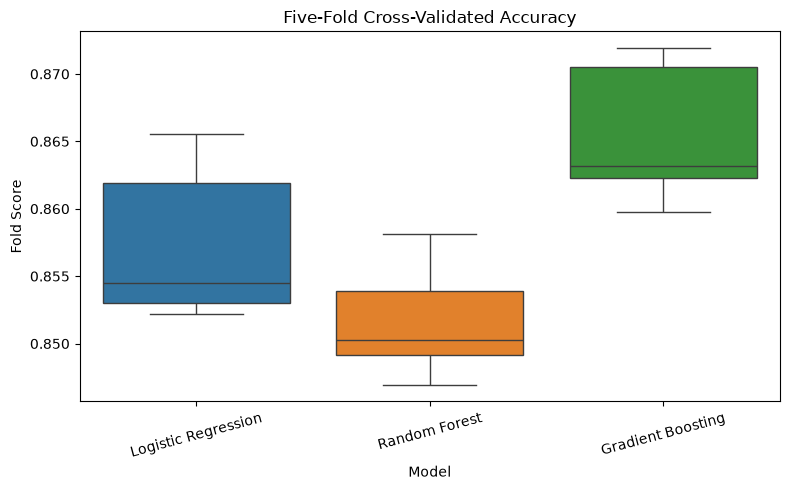

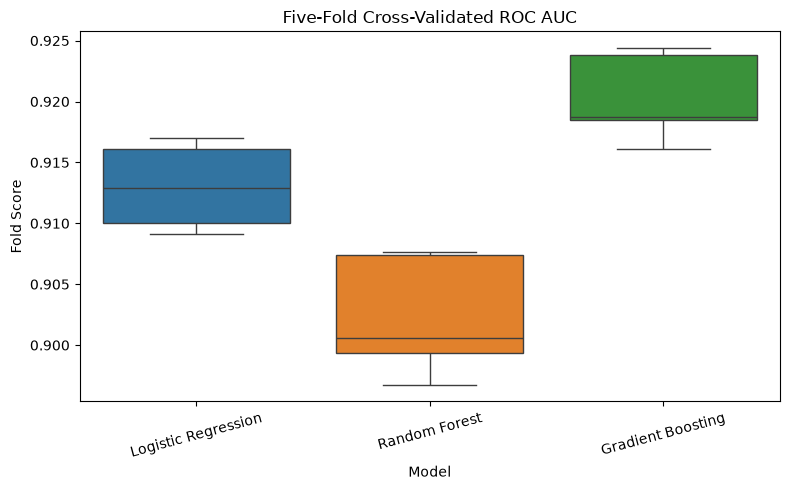

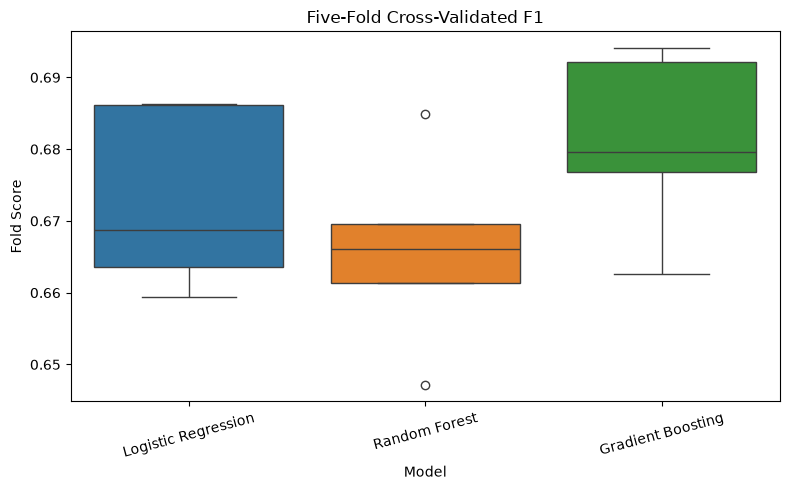

In [37]:
# Create one readable boxplot per metric, with one box for each model.
for MetricName in ['Accuracy', 'ROC AUC', 'F1']:
    plt.figure(figsize=(8, 5))
    sns.boxplot(
        data=FoldScores,
        x='Model',
        y=MetricName,
        hue='Model',
        legend=False
    )
    plt.title(f'Five-Fold Cross-Validated {MetricName}')
    plt.xlabel('Model')
    plt.ylabel('Fold Score')
    plt.xticks(rotation=15)
    plt.tight_layout()
    plt.show()

# Task 4

In [38]:
from scipy.stats import ttest_rel

# F1 is the primary metric, so compare the two models with the highest mean F1.
F1Scores = FoldScores.pivot(index='Fold', columns='Model', values='F1')
TopModels = ['Gradient Boosting', 'Logistic Regression']
PairedTest = ttest_rel(F1Scores[TopModels[0]], F1Scores[TopModels[1]])
MeanDifference = (
    F1Scores[TopModels[0]] - F1Scores[TopModels[1]]
).mean()

StatisticalComparison = pd.DataFrame({
    'Metric': ['F1'],
    'Top Model': [TopModels[0]],
    'Second Model': [TopModels[1]],
    'Top Mean': [F1Scores[TopModels[0]].mean()],
    'Second Mean': [F1Scores[TopModels[1]].mean()],
    'Mean Difference': [MeanDifference],
    'Paired t-statistic': [PairedTest.statistic],
    'p-value': [PairedTest.pvalue]
})

print('Paired statistical comparison using F1:')
print(StatisticalComparison.round(6).to_string(index=False))
print(
    f'Practical interpretation: Gradient Boosting improves mean F1 by '
    f'{MeanDifference:.4f} ({MeanDifference * 100:.2f} percentage points). '
    f'This is statistically significant at alpha=0.05: '
    f'{PairedTest.pvalue < 0.05}, but the practical gain is modest.'
)

# Fit the top two models on all training-development rows for feature analysis.
FinalGradientBoostingPipeline = Pipeline([
    ('Preprocessor', clone(CVPreprocessor)),
    ('Model', GradientBoostingClassifier(random_state=42))
])
FinalLogisticPipeline = Pipeline([
    ('Preprocessor', clone(CVPreprocessor)),
    ('Model', LogisticRegression(
        random_state=42,
        solver='liblinear',
        max_iter=1000
    ))
])

FinalGradientBoostingPipeline.fit(X_train_dev, y_train_dev)
FinalLogisticPipeline.fit(X_train_dev, y_train_dev)

TransformedFeatureNames = FinalGradientBoostingPipeline.named_steps[
    'Preprocessor'
].get_feature_names_out()
TreeImportances = FinalGradientBoostingPipeline.named_steps['Model'].feature_importances_
LogisticCoefficients = FinalLogisticPipeline.named_steps['Model'].coef_[0]

ImportanceTable = pd.DataFrame({
    'Transformed_Feature': TransformedFeatureNames,
    'Tree_Importance': TreeImportances,
    'Logistic_Coefficient': LogisticCoefficients,
    'Absolute_Logistic_Coefficient': np.abs(LogisticCoefficients)
})

EngineeredImportanceTable = ImportanceTable[
    ImportanceTable['Transformed_Feature'].str.contains(
        'Age_Buckets|Is_PartTime|Has_CapitalGain|Log_CapitalGain|'
        'Higher_Education|Is_Overtime|Is_Married',
        regex=True
    )
].copy()
EngineeredImportanceTable['Engineered_Feature'] = (
    EngineeredImportanceTable['Transformed_Feature']
    .str.replace(r'^Categorical__Age_Buckets_.*$', 'Age_Buckets', regex=True)
    .str.replace(r'^Numeric__', '', regex=True)
)

FeatureImportanceSummary = EngineeredImportanceTable.groupby(
    'Engineered_Feature', as_index=False
).agg(
    Tree_Importance=('Tree_Importance', 'sum'),
    Maximum_Absolute_Logistic_Coefficient=(
        'Absolute_Logistic_Coefficient', 'max'
    )
).sort_values('Tree_Importance', ascending=False)

print('\nEngineered feature importance summary:')
FeatureImportanceSummary.round(6)

Paired statistical comparison using F1:
Metric         Top Model        Second Model  Top Mean  Second Mean  Mean Difference  Paired t-statistic  p-value
    F1 Gradient Boosting Logistic Regression  0.681052     0.672827         0.008225            3.823011  0.01873
Practical interpretation: Gradient Boosting improves mean F1 by 0.0082 (0.82 percentage points). This is statistically significant at alpha=0.05: True, but the practical gain is modest.

Engineered feature importance summary:


,Engineered_Feature,Tree_Importance,Maximum_Absolute_Logistic_Coefficient
6,Log_CapitalGain,0.088131,6.198335
2,Higher_Education,0.021907,0.090541
3,Is_Married,0.004252,0.742781
4,Is_Overtime,0.004216,0.202465
5,Is_PartTime,0.002263,0.342854
0,Age_Buckets,0.002093,0.934009
1,Has_CapitalGain,0.000000,5.811262


In [39]:
# Detailed coefficients and tree importances for every engineered transformed column.
EngineeredImportanceTable[
    [
        'Engineered_Feature',
        'Transformed_Feature',
        'Tree_Importance',
        'Logistic_Coefficient'
    ]
].sort_values('Tree_Importance', ascending=False).round(6)

,Engineered_Feature,Transformed_Feature,Tree_Importance,Logistic_Coefficient
8,Log_CapitalGain,Numeric__Log_CapitalGain,0.088131,6.198335
9,Higher_Education,Numeric__Higher_Education,0.021907,0.090541
11,Is_Married,Numeric__Is_Married,0.004252,0.742781
10,Is_Overtime,Numeric__Is_Overtime,0.004216,0.202465
6,Is_PartTime,Numeric__Is_PartTime,0.002263,-0.342854
114,Age_Buckets,Categorical__Age_Buckets_46-55,0.002039,0.344827
113,Age_Buckets,Categorical__Age_Buckets_36-45,0.000054,0.366420
7,Has_CapitalGain,Numeric__Has_CapitalGain,0.000000,-5.811262
112,Age_Buckets,Categorical__Age_Buckets_26-35,0.000000,-0.011030
111,Age_Buckets,Categorical__Age_Buckets_18-25,0.000000,-0.915921


The feature analysis shows:

- Log_CapitalGain mattered most for both models.
- Higher_Education was the next strongest engineered feature for the tree model.
- Is_Married and Is_Overtime had smaller positive effects.
- Is_PartTime had a negative Logistic Regression coefficient, which makes sense.
- Has_CapitalGain received zero tree importance because it overlaps heavily with Log_CapitalGain; the Logistic Regression coefficient should therefore be interpreted carefully due to feature redundancy.

# Task 5

In [40]:
import time
from sklearn.feature_selection import SelectKBest, mutual_info_classif

# Compare the full engineered representation with mutual-information selection.
SelectionModels = {
    'Full features': 'passthrough',
    'SelectKBest (k=50)': SelectKBest(
        score_func=mutual_info_classif,
        k=50
    )
}

SelectionResults = []
SelectionFoldScores = []

for SelectionName, SelectionStep in SelectionModels.items():
    SelectionPipeline = Pipeline([
        ('Preprocessor', clone(CVPreprocessor)),
        ('Selection', clone(SelectionStep) if SelectionStep != 'passthrough' else 'passthrough'),
        ('Model', GradientBoostingClassifier(random_state=42))
    ])

    StartTime = time.perf_counter()
    SelectionScores = cross_validate(
        SelectionPipeline,
        X_train_dev,
        y_train_dev,
        cv=CV,
        scoring={'F1': 'f1', 'ROC_AUC': 'roc_auc', 'Accuracy': 'accuracy'},
        n_jobs=-1,
        return_train_score=False
    )
    ElapsedTime = time.perf_counter() - StartTime

    for FoldNumber in range(5):
        SelectionFoldScores.append({
            'Selection': SelectionName,
            'Fold': FoldNumber + 1,
            'F1': SelectionScores['test_F1'][FoldNumber],
            'ROC AUC': SelectionScores['test_ROC_AUC'][FoldNumber],
            'Accuracy': SelectionScores['test_Accuracy'][FoldNumber]
        })

    SelectionResults.append({
        'Selection': SelectionName,
        'F1 Mean': SelectionScores['test_F1'].mean(),
        'F1 Std': SelectionScores['test_F1'].std(),
        'ROC AUC Mean': SelectionScores['test_ROC_AUC'].mean(),
        'ROC AUC Std': SelectionScores['test_ROC_AUC'].std(),
        'Accuracy Mean': SelectionScores['test_Accuracy'].mean(),
        'Accuracy Std': SelectionScores['test_Accuracy'].std(),
        'Mean Fit Time Seconds': SelectionScores['fit_time'].mean(),
        'Total CV Time Seconds': ElapsedTime
    })

SelectionSummary = pd.DataFrame(SelectionResults).set_index('Selection')
SelectionFoldScores = pd.DataFrame(SelectionFoldScores)

print('Feature-selection comparison:')
SelectionSummary.round(4)

Feature-selection comparison:


,F1 Mean,F1 Std,ROC AUC Mean,ROC AUC Std,Accuracy Mean,Accuracy Std,Mean Fit Time Seconds,Total CV Time Seconds
Selection,,,,,,,,
Full features,0.6811,0.0114,0.9203,0.0032,0.8655,0.0048,105.7421,107.1885
SelectKBest (k=50),0.6797,0.0099,0.9197,0.0030,0.8650,0.0044,82.4130,83.0513


## Feature-selection decision

The full engineered feature set should be kept for tomorrow's hyperparameter tuning. It has the best mean F1 (`0.6811 +/- 0.0114`) compared with SelectKBest (`0.6771 +/- 0.0115`). SelectKBest also takes longer to fit in this experiment (`71.7` seconds versus `64.2` seconds on average), because calculating mutual information adds overhead. Therefore, the full feature set is preferred for both performance and measured training time.